# Legge dei grandi numeri

In [574]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statistics
import math

## Distribuzione uniforme

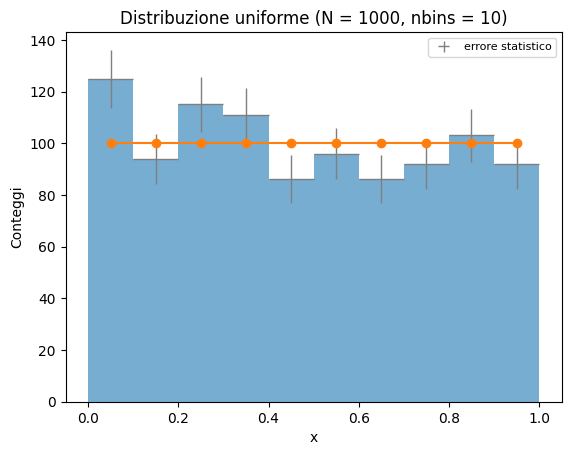

In [575]:
n=1000
u = np.random.uniform(0, 1, n)
h, bins, patches = plt.hist(u, range=(0,1), bins=10, alpha=0.6)
larghezza_bin=1/10
centri_bin= bins[:-1] + larghezza_bin/2
pi=1/n
mu=100
lista = [mu] * 10

plt.errorbar(centri_bin, h, np.sqrt(h), larghezza_bin/2, c='tab:grey', lw=1, fmt='none',label="errore statistico")
plt.xlabel("x")
plt.ylabel("Conteggi")
plt.title(f"Distribuzione uniforme (N = {n}, nbins = {10})")
plt.legend(loc='best', prop={'size': 8})
plt.plot(centri_bin, lista, label='Dati', marker='o', linestyle='solid') #(ascisse, ordinate, etichetta, marker, stile della linea)
plt.show()


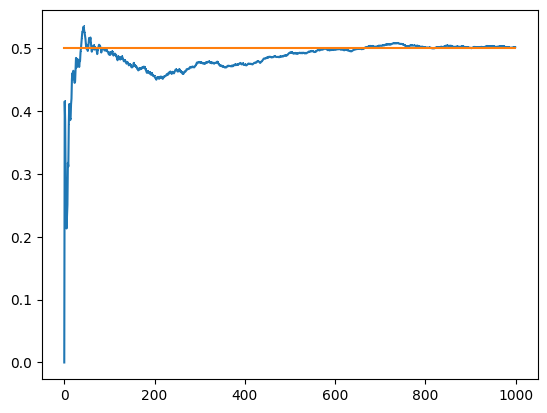

In [576]:
n=1000
medie=[0]
osservazioni=[0]
u = np.random.uniform(0, 1, n)
for i in range (1,n):
    media=statistics.mean(u[:i])
    medie.append(media)
    osservazioni.append(i)

plt.plot(osservazioni, medie, label='Dati', marker=',', linestyle='solid') #(ascisse, ordinate, etichetta, marker, stile della linea)
plt.plot(osservazioni,[0.5]*(n))
plt.show()

    


## Distribuzione esponenziale

In [577]:
def distribuzione_esponenziale(x,t):
    valori=(np.exp(-x/t))/t
    return valori

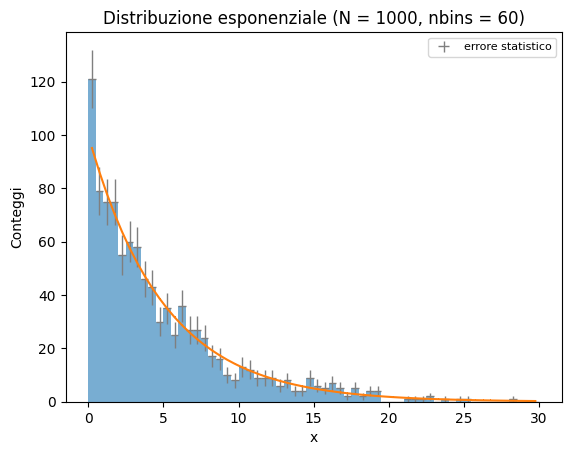

In [578]:
n=1000
u = np.random.uniform(0, 1, n)
t = 5
e = -5*np.log(1-u)
h, bins, patches = plt.hist(e, range=(0,30), bins=60, alpha=0.6)
larghezza_bin= (bins[1] - bins[0])
centri_bin= (bins[:-1] + bins[1:])/2

valori_exp=distribuzione_esponenziale(centri_bin,t)*larghezza_bin*n
plt.errorbar(centri_bin, h, np.sqrt(h), larghezza_bin/2, c='tab:grey', lw=1, fmt='none', label="errore statistico")
plt.xlabel("x")
plt.ylabel("Conteggi")
plt.title(f"Distribuzione esponenziale (N = {n}, nbins = {60})")
plt.legend(loc='best', prop={'size': 8})
plt.plot(centri_bin, valori_exp, label='Dati', marker=',', linestyle='solid') #(ascisse, ordinate, etichetta, marker, stile della linea)
plt.show()

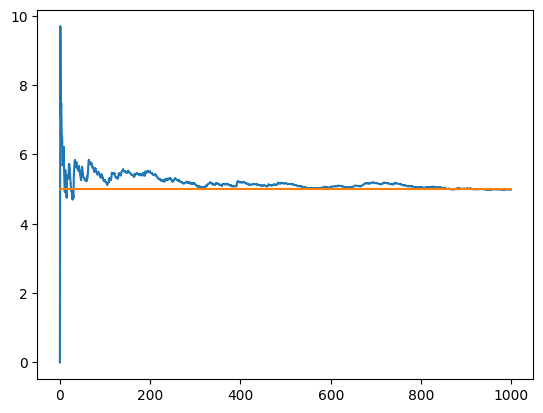

In [579]:
n=1000
medie=[0]
osservazioni=[0]
u = np.random.uniform(0, 1, n)
e = -5*np.log(1-u)
for i in range (1,n):
    media=statistics.mean(e[:i])
    medie.append(media)
    osservazioni.append(i)

plt.plot(osservazioni, medie, label='Dati', marker=',', linestyle='solid') #(ascisse, ordinate, etichetta, marker, stile della linea)
plt.plot(osservazioni,[5]*(n))
plt.show()


## Distribuzione di Cauchy

In [580]:
def distribuzione_cauchy(y):
    val=(1/np.pi)*(1/(1+y**2))
    return val


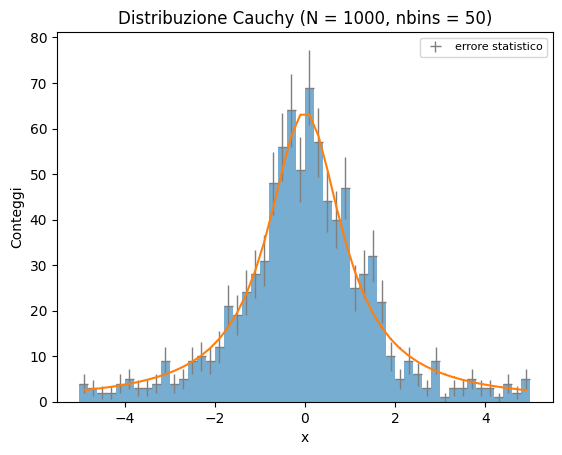

In [581]:
n=1000
u1=np.random.normal(0,1,n)
u2=np.random.normal(0,1,n)
c=u1/u2

h, bins, patches = plt.hist(c, range=(-5,5), bins=50, alpha=0.6)
larghezza_bin= (bins[1] - bins[0])
centri_bin= (bins[:-1] + bins[1:])/2

valori_cauchy= distribuzione_cauchy(centri_bin)*larghezza_bin*n
plt.errorbar(centri_bin, h, np.sqrt(h), larghezza_bin/2, c='tab:grey', lw=1, fmt='none', label="errore statistico")
plt.xlabel("x")
plt.ylabel("Conteggi")
plt.title(f"Distribuzione Cauchy (N = {n}, nbins = {50})")
plt.legend(loc='best', prop={'size': 8})
plt.plot(centri_bin, valori_cauchy, label='Dati', marker=',', linestyle='solid') #(ascisse, ordinate, etichetta, marker, stile della linea)
plt.show()


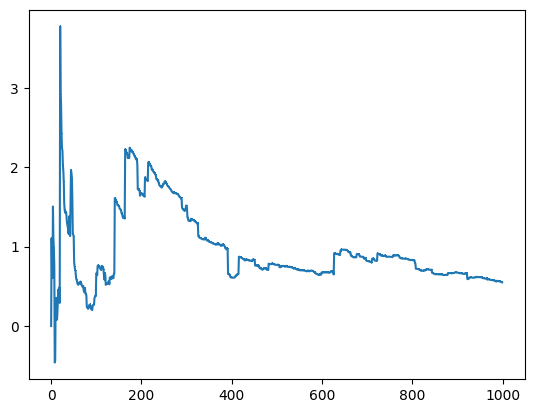

In [582]:
n=1000
medie=[0]
osservazioni=[0]
u1=np.random.normal(0,1,n)
u2=np.random.normal(0,1,n)
c=u1/u2
for i in range (1,n):
    media=statistics.mean(c[:i])
    medie.append(media)
    osservazioni.append(i)

plt.plot(osservazioni, medie, label='Dati', marker=',', linestyle='solid') #(ascisse, ordinate, etichetta, marker, stile della linea)
plt.show()

# Teorema del limite centrale

## Distribuzione uniforme

In [583]:
def gaussian_pdf(x, mu=0, sigma=1):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

In [584]:

def plot_histo_gauss(z, titolo, data1, data2, data3, bins=80, x_range=(-4,4)):
    if z==0:
        fig, axes = plt.subplots(1, 3, figsize=(15,5))

        datasets = [data1, data2, data3]
        titles = ['Dataset 1', 'Dataset 2', 'Dataset 3']

        for ax, data, t in zip(axes, datasets, titles):
            # calcolo istogramma senza disegnare subito
            h, bin_edges = np.histogram(data, bins=bins, range=x_range)
            delta_x = bin_edges[1] - bin_edges[0]
            centri = (bin_edges[:-1] + bin_edges[1:]) / 2

            # disegno istogramma
            ax.bar(centri, h, width=delta_x, alpha=0.6, label='Dati')

            # barre di errore Poisson
            ax.errorbar(centri, h, yerr=np.sqrt(h), xerr=delta_x/2,
                        fmt='none', color='grey', lw=1, label='Errore Poisson')

            # curva normale standard (PDF moltiplicata per n*Δx)
            ax.plot(centri, gaussian_pdf(centri)*len(data)*delta_x,
                    color='red', label='Normale standard')

            ax.set_title(t)
            ax.set_xlabel('x')
            ax.set_ylabel('Conteggi')
            ax.legend(fontsize=8)

        fig.suptitle(titolo)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
    else:  
        fig, axes = plt.subplots(1, 3, figsize=(15,5))
        datasets = [data1, data2, data3]
        titles = ['Dataset 1', 'Dataset 2', 'Dataset 3']

        for ax, data, t in zip(axes, datasets, titles):
            # calcolo istogramma senza disegnare subito
            h, bin_edges = np.histogram(data, bins=bins, range=x_range)
            delta_x = bin_edges[1] - bin_edges[0]
            centri = (bin_edges[:-1] + bin_edges[1:]) / 2

            # disegno istogramma
            ax.bar(centri, h, width=delta_x, alpha=0.6, label='Dati')

            # barre di errore Poisson
            ax.errorbar(centri, h, yerr=np.sqrt(h), xerr=delta_x/2,
                        fmt='none', color='grey', lw=1, label='Errore Poisson')

            # curva normale standard (PDF moltiplicata per n*Δx)
            ax.plot(centri, gaussian_pdf(centri)*len(data)*delta_x,
                    color='red', label='Normale standard')

            valori_cauchy= distribuzione_cauchy(centri)*delta_x*len(data)
            ax.plot(centri, valori_cauchy, label='Dati', marker=',', linestyle='solid') #(ascisse, ordinate, etichetta, marker, stile della linea)
            ax.set_title(t)
            ax.set_xlabel('x')
            ax.set_ylabel('Conteggi')
            ax.legend(fontsize=8)
            


        fig.suptitle(titolo)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

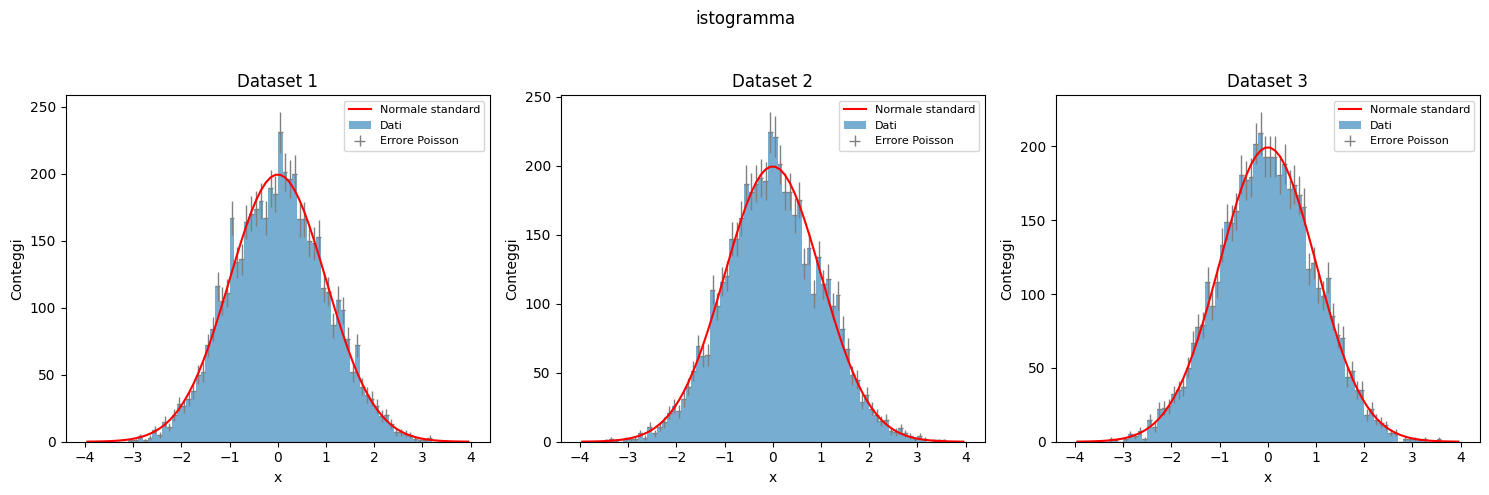

In [585]:
n=[5,30,100]
m=5000
mu=0.5
sigma=np.sqrt(1/12)

data=[]
for i in range(0,3):
    Q_val=[]
    for j in range(m):
        u= np.random.uniform(0,1,n[i])
        media=statistics.mean(u)
        Q= (media - mu)/(sigma/(np.sqrt(n[i])))
        Q_val.append(Q)
    data.append(Q_val)
plot_histo_gauss(0,'istogramma', data[0], data[1], data[2])


## Distribuzione esponenziale

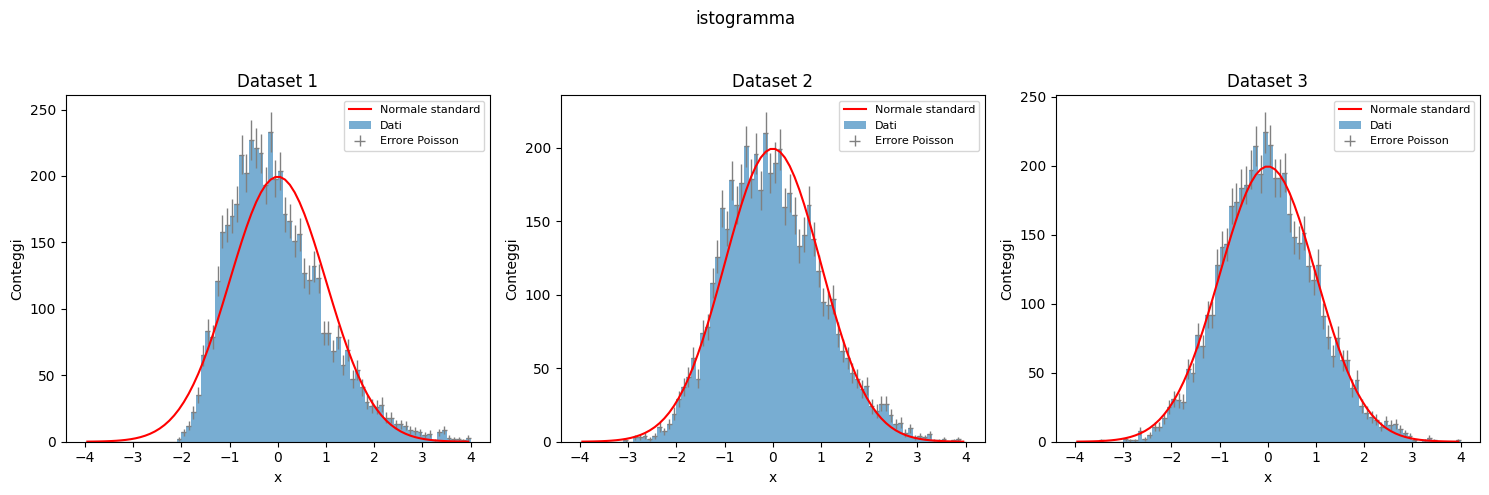

In [586]:
n=[5,30,100]
m=5000
mu=5
sigma=5
t = 5
data=[]
for i in range(0,3):
    Q_val=[]
    for j in range(m):
        u= np.random.uniform(0,1,n[i])
        e = -5*np.log(1-u)
        media=statistics.mean(e)
        Q= (media - mu)/(sigma/(np.sqrt(n[i])))
        Q_val.append(Q)
    data.append(Q_val)
plot_histo_gauss(0,'istogramma', data[0], data[1], data[2])

## Distribuzione di Cauchy

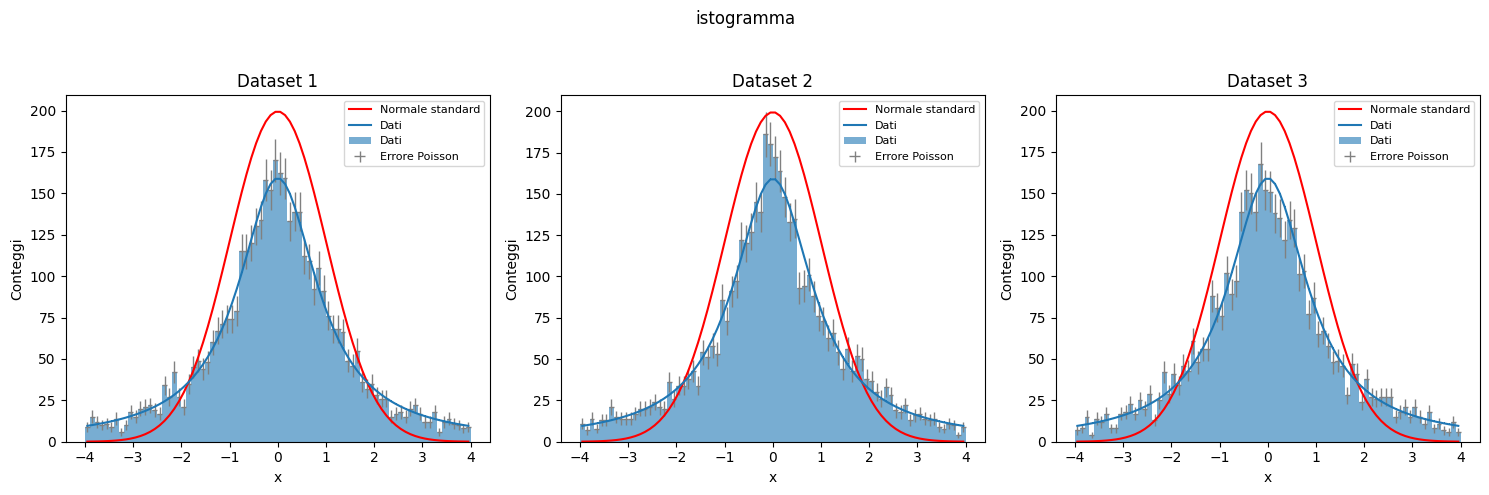

In [587]:
n=[5,30,100]
m=5000

data=[]
for i in range(0,3):
    Q_val=[]
    for j in range(m):
        u1= np.random.normal(0,1,n[i])
        u2=  np.random.normal(0,1,n[i])
        c = u1/u2
        media=statistics.mean(c)
        Q=media 
        Q_val.append(Q)
    data.append(Q_val)
plot_histo_gauss(5, 'istogramma', data[0], data[1], data[2])
